In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerPatch
import networkx as nx

In [6]:
################################################
# Skeleton code for Homework 4 Question 1
# MAE 6870 Engineering Collective Intelligence
# Cornell University, Fall 2025
# Prof. Anastasia Bizyaeva
#################################################

# ==============================
# Utilities
# ==============================
def circle_points(n, radius):
    """Equally spaced points on a circle (counterclockwise) in R^2."""
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    xy = np.stack([radius*np.cos(angles), radius*np.sin(angles)], axis=1)
    return xy

def antipodal_goals(x0):
    """Goal for agent i is the antipode of its initial position (i+N/2 mod N)."""
    n = x0.shape[0]
    assert n % 2 == 0, "Antipodal swap needs an even number of robots."
    perm = [(i + n//2) % n for i in range(n)]
    goals = x0[perm].copy()
    return goals

def unit_vector(v, eps=1e-9):
    nrm = np.linalg.norm(v)
    return v / max(nrm, eps)

def nominal_velocity(x, g, vmag):
    """Straight-line constant-speed nominal velocity from x to g."""
    d = g - x
    d_norm = np.linalg.norm(d)
    if d_norm < 1e-9:
        return np.zeros(2)
    return vmag * d / d_norm

def pairwise_cbf_halfspaces_for_agent(i, X, U_nom, dmin, alpha):
    """
    Build half-space constraints A u_i >= b for agent i:
      2 (p_i - p_j)^T u_i >= -alpha h_ij + 2 (p_i - p_j)^T u_j_nom
      with h_ij = ||p_i - p_j||^2 - dmin^2.
    Returns A (k x 2), b (k,), one row per neighbor j.
    """
    pi = X[i]
    Ai = []
    bi = []
    for j in range(X.shape[0]):
        if j == i:
            continue
        pj = X[j]
        dij = pi - pj
        h_ij = np.dot(dij, dij) - dmin**2
        a = 2.0 * dij                      # row vector acting on u_i
        rhs = -alpha * h_ij + 2.0 * np.dot(dij, U_nom[j])
        Ai.append(a)
        bi.append(rhs)
    if len(Ai) == 0:
        return np.zeros((0,2)), np.zeros((0,))
    return np.vstack(Ai), np.array(bi)

def project_onto_halfspace(u, a, c):
    """
    Project u onto {x | a^T x >= c}. Closed-form Euclidean projection.
    If a^T u >= c, return u. Else return u + ((c - a^T u)/||a||^2) a.
    """
    at_u = float(a @ u)
    if at_u >= c:
        return u
    a_norm2 = float(a @ a)
    if a_norm2 < 1e-12:
        return u  # degenerate
    return u + ((c - at_u) / a_norm2) * a

def project_u_nom_via_dykstra(u0, A, b, max_cycles=20):
    """
    Dykstra-style cyclic projections onto half-spaces A_k u >= b_k.
    Returns the Euclidean projection of u0 onto the intersection (good approx in few cycles).
    """
    u = u0.copy()
    # Dykstra corrections, one per constraint
    R = np.zeros_like(A)
    if A.shape[0] == 0:
        return u
    for _ in range(max_cycles):
        for k in range(A.shape[0]):
            a = A[k]
            c = b[k]
            y = u + R[k]
            u_new = project_onto_halfspace(y, a, c)
            R[k] = y - u_new
            u = u_new
    return u

def clamp_speed(u, vmax): # imposes a speed limit 
    nrm = np.linalg.norm(u)
    if nrm <= vmax:
        return u
    return (vmax / nrm) * u

# --- custom handler that draws a circle inside the legend box ---
def _legend_circle(legend, orig_handle, xdescent, ydescent, width, height, fontsize):
    cx = xdescent + width/2.0
    cy = ydescent + height/2.0
    r  = 0.45 * min(width, height)
    return mpatches.Circle((cx, cy), r,
                           fill=False,
                           linestyle=orig_handle.get_linestyle(),
                           edgecolor=orig_handle.get_edgecolor(),
                           linewidth=orig_handle.get_linewidth())

In [7]:

# ==============================
# Scenario and model parameters
# ==============================
N = 8                     # number of robots
R_circle = 6.0             # initial/goal circle radius
v_nom = 0.8                # nominal constant speed (m/s)
dt = 0.05                  # time step (s)
T_max = 30.0               # max sim time (s)
goal_tol = 0.01            # stop when all within this distance to goal (m)

# Robot geometry & CBF safety
robot_radius = 0.50        # disk radius (m)
safety_margin = 0.2        # extra cushion (m)
d_min = 2.0*robot_radius + safety_margin   # minimum allowed center-to-center distance
alpha = 2.0                # CBF class-K slope (1/s)

# Deadlock tie-breaker (set to 0.0 to disable)
bias_strength = 0.00       # m/s magnitude of small orthogonal bias

# ==============================
# Set up initial/goal states
# ==============================
X0 = circle_points(N, R_circle)       # (N,2)
G  = antipodal_goals(X0)              # (N,2)
X  = X0.copy()
traj = [X.copy()]
Us = []

# ==============================
# Simulation loop
# ==============================
t = 0.0
t_lst = [t]
num_steps = int(np.ceil(T_max / dt))
with_cbf = True   # toggle to False to see the (colliding) nominal behavior

for step in range(num_steps):
    # Stop if all goals reached
    if np.all(np.linalg.norm(G - X, axis=1) <= goal_tol):
        break
    # Nominal velocities
    U_nom = np.zeros_like(X)
    for i in range(N):
        U_nom[i] = nominal_velocity(X[i], G[i], v_nom) 

    # CBF filtering (decentralized; each agent uses others' U_nom as u_j)
    if with_cbf:
        U = np.zeros_like(X)
        for i in range(N):
            A_i, b_i = pairwise_cbf_halfspaces_for_agent(i, X, U_nom, d_min, alpha)
            u_proj = project_u_nom_via_dykstra(U_nom[i], A_i, b_i, max_cycles=25)
            U[i] = clamp_speed(u_proj, v_nom)  # keep same speed cap
    else:
        U = U_nom

    # Integrate
    X = X + dt * U
    traj.append(X.copy())
    Us.append(U.copy())
    t += dt
    t_lst.append(t)

traj = np.stack(traj, axis=0)  # (T, N, 2)
Us = np.stack(Us, axis=0)
print(f"Simulated {traj.shape[0]} steps, final mean goal error:",
      np.mean(np.linalg.norm(G - X, axis=1)))

Simulated 601 steps, final mean goal error: 7.780580189071508


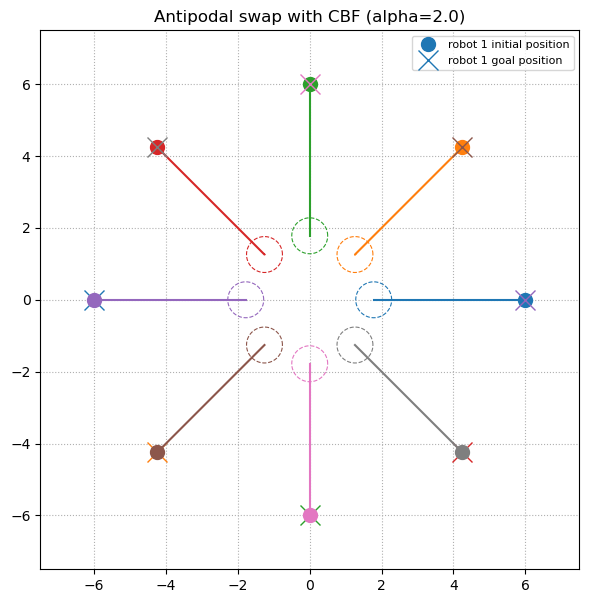

In [8]:
# Visualization
plot_every = 2             # draw every k steps (for speed)
trail_len = traj.shape[0]            # number of past positions to show per agent

# ==============================
# Plot
# ==============================
colors = plt.cm.tab10(np.arange(N) % 10)
fig, ax = plt.subplots(figsize=(7,7))
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-R_circle-1.5, R_circle+1.5)
ax.set_ylim(-R_circle-1.5, R_circle+1.5)
ax.set_title(f"Antipodal swap with {'CBF' if with_cbf else 'no CBF'} (alpha={alpha})")

# draw safety disks at final positions (for visualization)
theta = np.linspace(0, 2*np.pi, 60)
circle = np.stack([np.cos(theta), np.sin(theta)], axis=1)

for i in range(N):
    # trail
    tt = traj[-trail_len:, i, :]
    ax.plot(tt[:,0], tt[:,1], lw=1.5, color=colors[i])
    # start and goal
    ax.plot(X0[i,0], X0[i,1], 'o', color=colors[i], ms=10, label=f"robot {i+1} initial position" if i==0 else None)
    ax.plot(G[i,0],  G[i,1],  'x', color=colors[i], ms=15,label=f"robot {i+1} goal position" if i==0 else None)
    # final disk
    circ = X[i] + robot_radius*circle  #+ d_min/2.0 * circle  # half of d_min is visual buffer; true body radius is robot_radius
    ax.plot(circ[:,0], circ[:,1], '--', color=colors[i], lw=0.8)

ax.legend(loc='upper right', frameon=True, fontsize=8)

ax.grid(True, ls=':')
plt.show()

In [20]:
print(d_min,d_min**2)

1.2 1.44


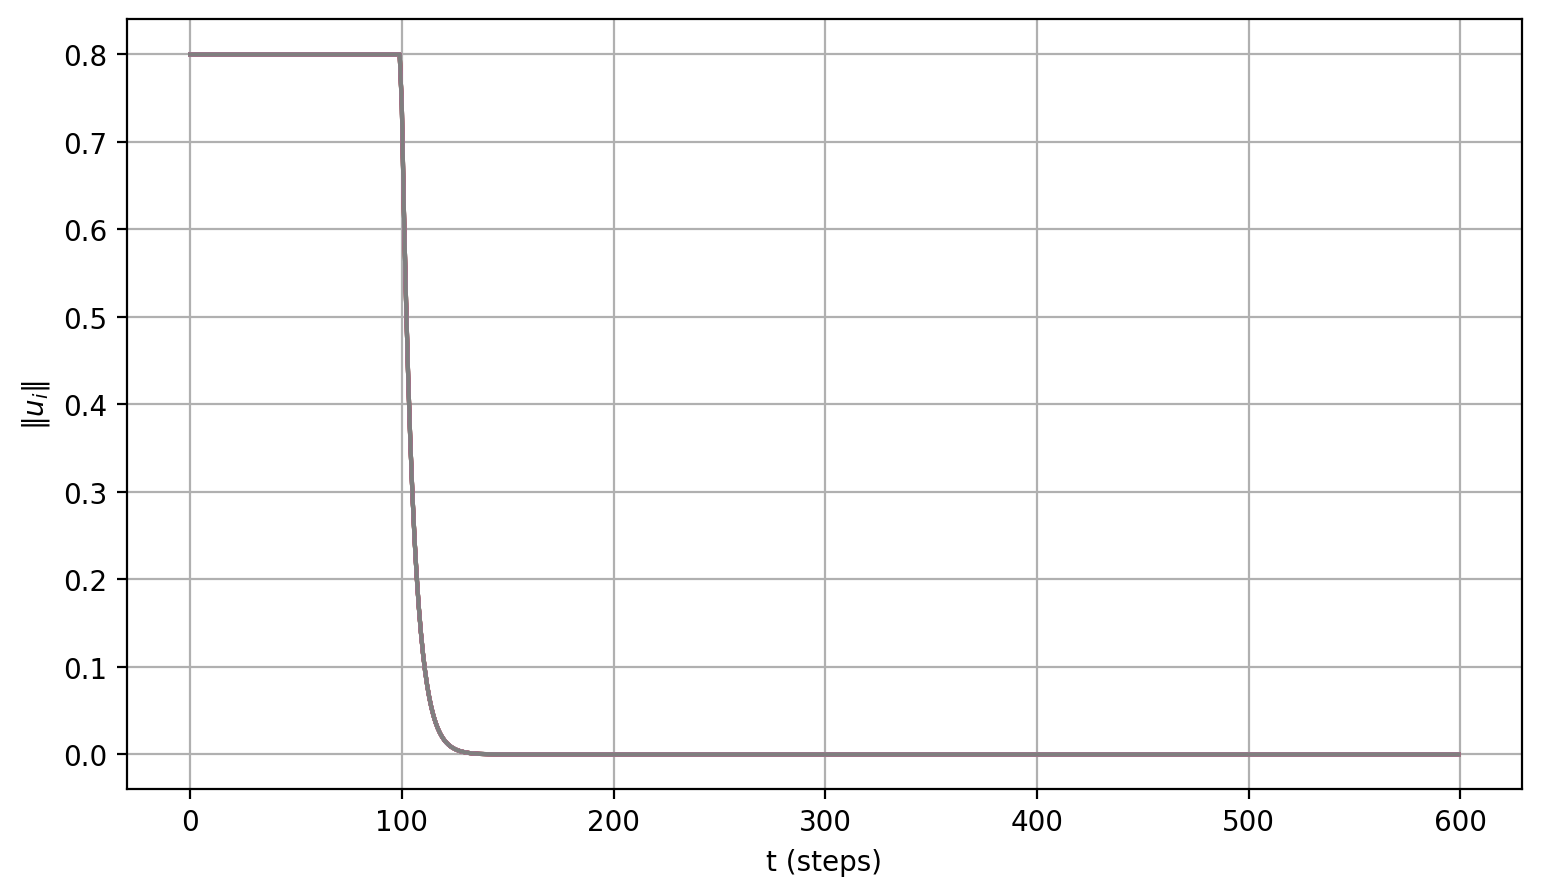

In [10]:
fig, ax = plt.subplots(figsize=(9,5),dpi = 200)
ax.set_xlabel("t (steps)")
ax.set_ylabel(r"$\|u_i\|$")
ax.grid()

for i in range(N):
    tt = Us[:, i ,:]
    ax.plot(np.linalg.norm(Us[:, i ,:],axis = 1))

In [ ]:
def compute_nominal_control_with_NOD(p,p_star, x, p_center, k, beta):
    U = np.zeros_like(p)

    for i in range(N):
        #get n_i, b_i using matrix multiplication, set u_i
        ni = unit_vector(p[i]-p_center) 
        bi = np.array([[0,-1],[1,0]])@ni
        U[i]= -k*(p[i] - p_star[i]) + beta*x[i]*bi
    return U

def compute_attention_and_bias(p, u_qp, A, nu_low, nu_high, v_th, kI, p_center):
    N = len(p)
    nu_t = np.zeros(N)
    I_t = np.zeros(N)
    
    # get average velocity/control
    vbar = np.mean(np.linalg.norm(u_qp, axis=1))
    
    # set attention values according to rule (global, but could be done accordng to graph)
    if vbar >v_th:
        nu_val = nu_low
    else:
        nu_val = nu_high
    nu_t[:] = nu_val
    
    # directional bias using cardinality counts
    for i in range(N):
        ni = unit_vector(p[i] - p_center)      
        bi = np.array([[0, -1], [1, 0]]) @ ni   # rotate using rotation matrix
        
        # compute determinants
        s_i = np.array([np.linalg.det(np.stack([bi, p[j]-p[i]]).T) for j in range(N)])
        
        # cardinality: number of positive and negative
        nileft  = np.count_nonzero(s_i > 0)
        niright = np.count_nonzero(s_i < 0)
        
        I_t[i] = kI * (niright - nileft)  # difference of counts
    
    return nu_t, I_t, vbar


def update_opinion_state(x, A, d, nu_t, I, dt):
    N = len(x)
    new_x = np.zeros_like(x) # setup array to get updated to
    
    for i in range(N):
        # compute part that goes inside tanh
        interaction = A[i,i]*x[i] + sum(A[i,j] * x[j] for j in range(N) if A[i,j] != 0) 

        # compute and set full update, have to use new_x to not mess up the time steps in the sum in the prev line
        new_x[i] = x[i] + dt * (-d[i]*x[i] + np.tanh(nu_t[i]*interaction) + I[i])
    
    return new_x

# ----------------------------
# Simulation parameters
# ----------------------------
X  = X0.copy()
x_op = np.zeros(N)      
traj = [X.copy()]
Us = []
opinion_lst = [x_op.copy()]
nu_lst = []
I_lst = []
vbar_lst = []
t_lst = [0.0]
t = 0.0
num_steps = int(np.ceil(T_max / dt))

A = np.ones((N,N)) - np.diag(np.ones(N))
nu_low = 0.1
nu_high = 2
v_th = 0.2
kI = 1
k = 1
p_center = np.array([0,0])
d = np.ones(N)
beta = 0.5


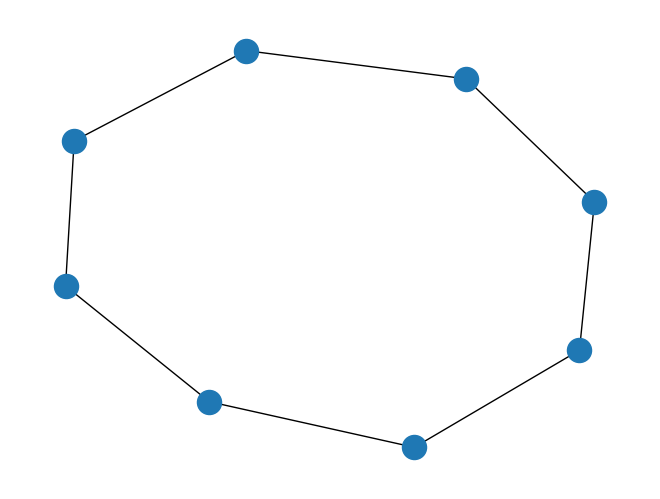

In [12]:

Gcycle = nx.cycle_graph(N)
Acycle = nx.to_numpy_array(Gcycle)
nx.draw(Gcycle)

In [13]:
X  = X0.copy()
x_op = np.zeros(N)      
traj = [X.copy()]
Us = []
opinion_lst = [x_op.copy()]
nu_lst = []
I_lst = []
vbar_lst = []
t_lst = [0.0]
t = 0.0
num_steps = int(np.ceil(T_max / dt))

#A = np.ones((N,N)) - np.diag(np.ones(N))
A = Acycle


nu_low = 0.01
nu_high = 2
v_th = 0.2
kI = 0.05
k = 0.2
p_center = np.array([0,0])
d = 5*np.ones(N)
beta = 0.1

# ----------------------------
# Main simulation loop
# ----------------------------


# initial Nominal velocities
U_nom = np.zeros_like(X)
for i in range(N):
    U_nom[i] = nominal_velocity(X[i], G[i], v_nom) 

U = U_nom

for step in range(num_steps):
    # Stop if all goals reached
    if np.all(np.linalg.norm(G - X, axis=1) <= goal_tol):
        break

    for i in range(N):
        A_i, b_i = pairwise_cbf_halfspaces_for_agent(i, X, U, d_min, alpha)
        u_proj = project_u_nom_via_dykstra(U[i], A_i, b_i, max_cycles=25)
        U[i] = clamp_speed(u_proj, v_nom)  # keep same speed cap
# Compute formation-only nominal control

    # Compute attention/bias from NOD-augmented velocities (pre-CBF)
    nu_t, I_t, vbar = compute_attention_and_bias(X, U, A, nu_low, nu_high, v_th, kI, p_center)

    #  Update opinion
    x_op = update_opinion_state(x_op, A, d, nu_t, I_t, dt)


    #Compute NOD-augmented nominal control using current opinion
    U_nod = compute_nominal_control_with_NOD(X, G, x_op, p_center, k, beta)

    # CBF-QP 
    for i in range(N):
        A_i, b_i = pairwise_cbf_halfspaces_for_agent(i, X, U_nod, d_min, alpha)
        u_proj = project_u_nom_via_dykstra(U_nod[i], A_i, b_i, max_cycles=25)
        U[i] = clamp_speed(u_proj, v_nom)

    # 7. Integrate
    X = X + dt * U


    # ----------------------------
    # Store data for plotting
    # ----------------------------
    traj.append(X.copy())
    Us.append(U.copy())
    opinion_lst.append(x_op.copy())
    nu_lst.append(nu_t.copy())
    I_lst.append(I_t.copy())
    vbar_lst.append(float(vbar))
    t += dt
    t_lst.append(t)

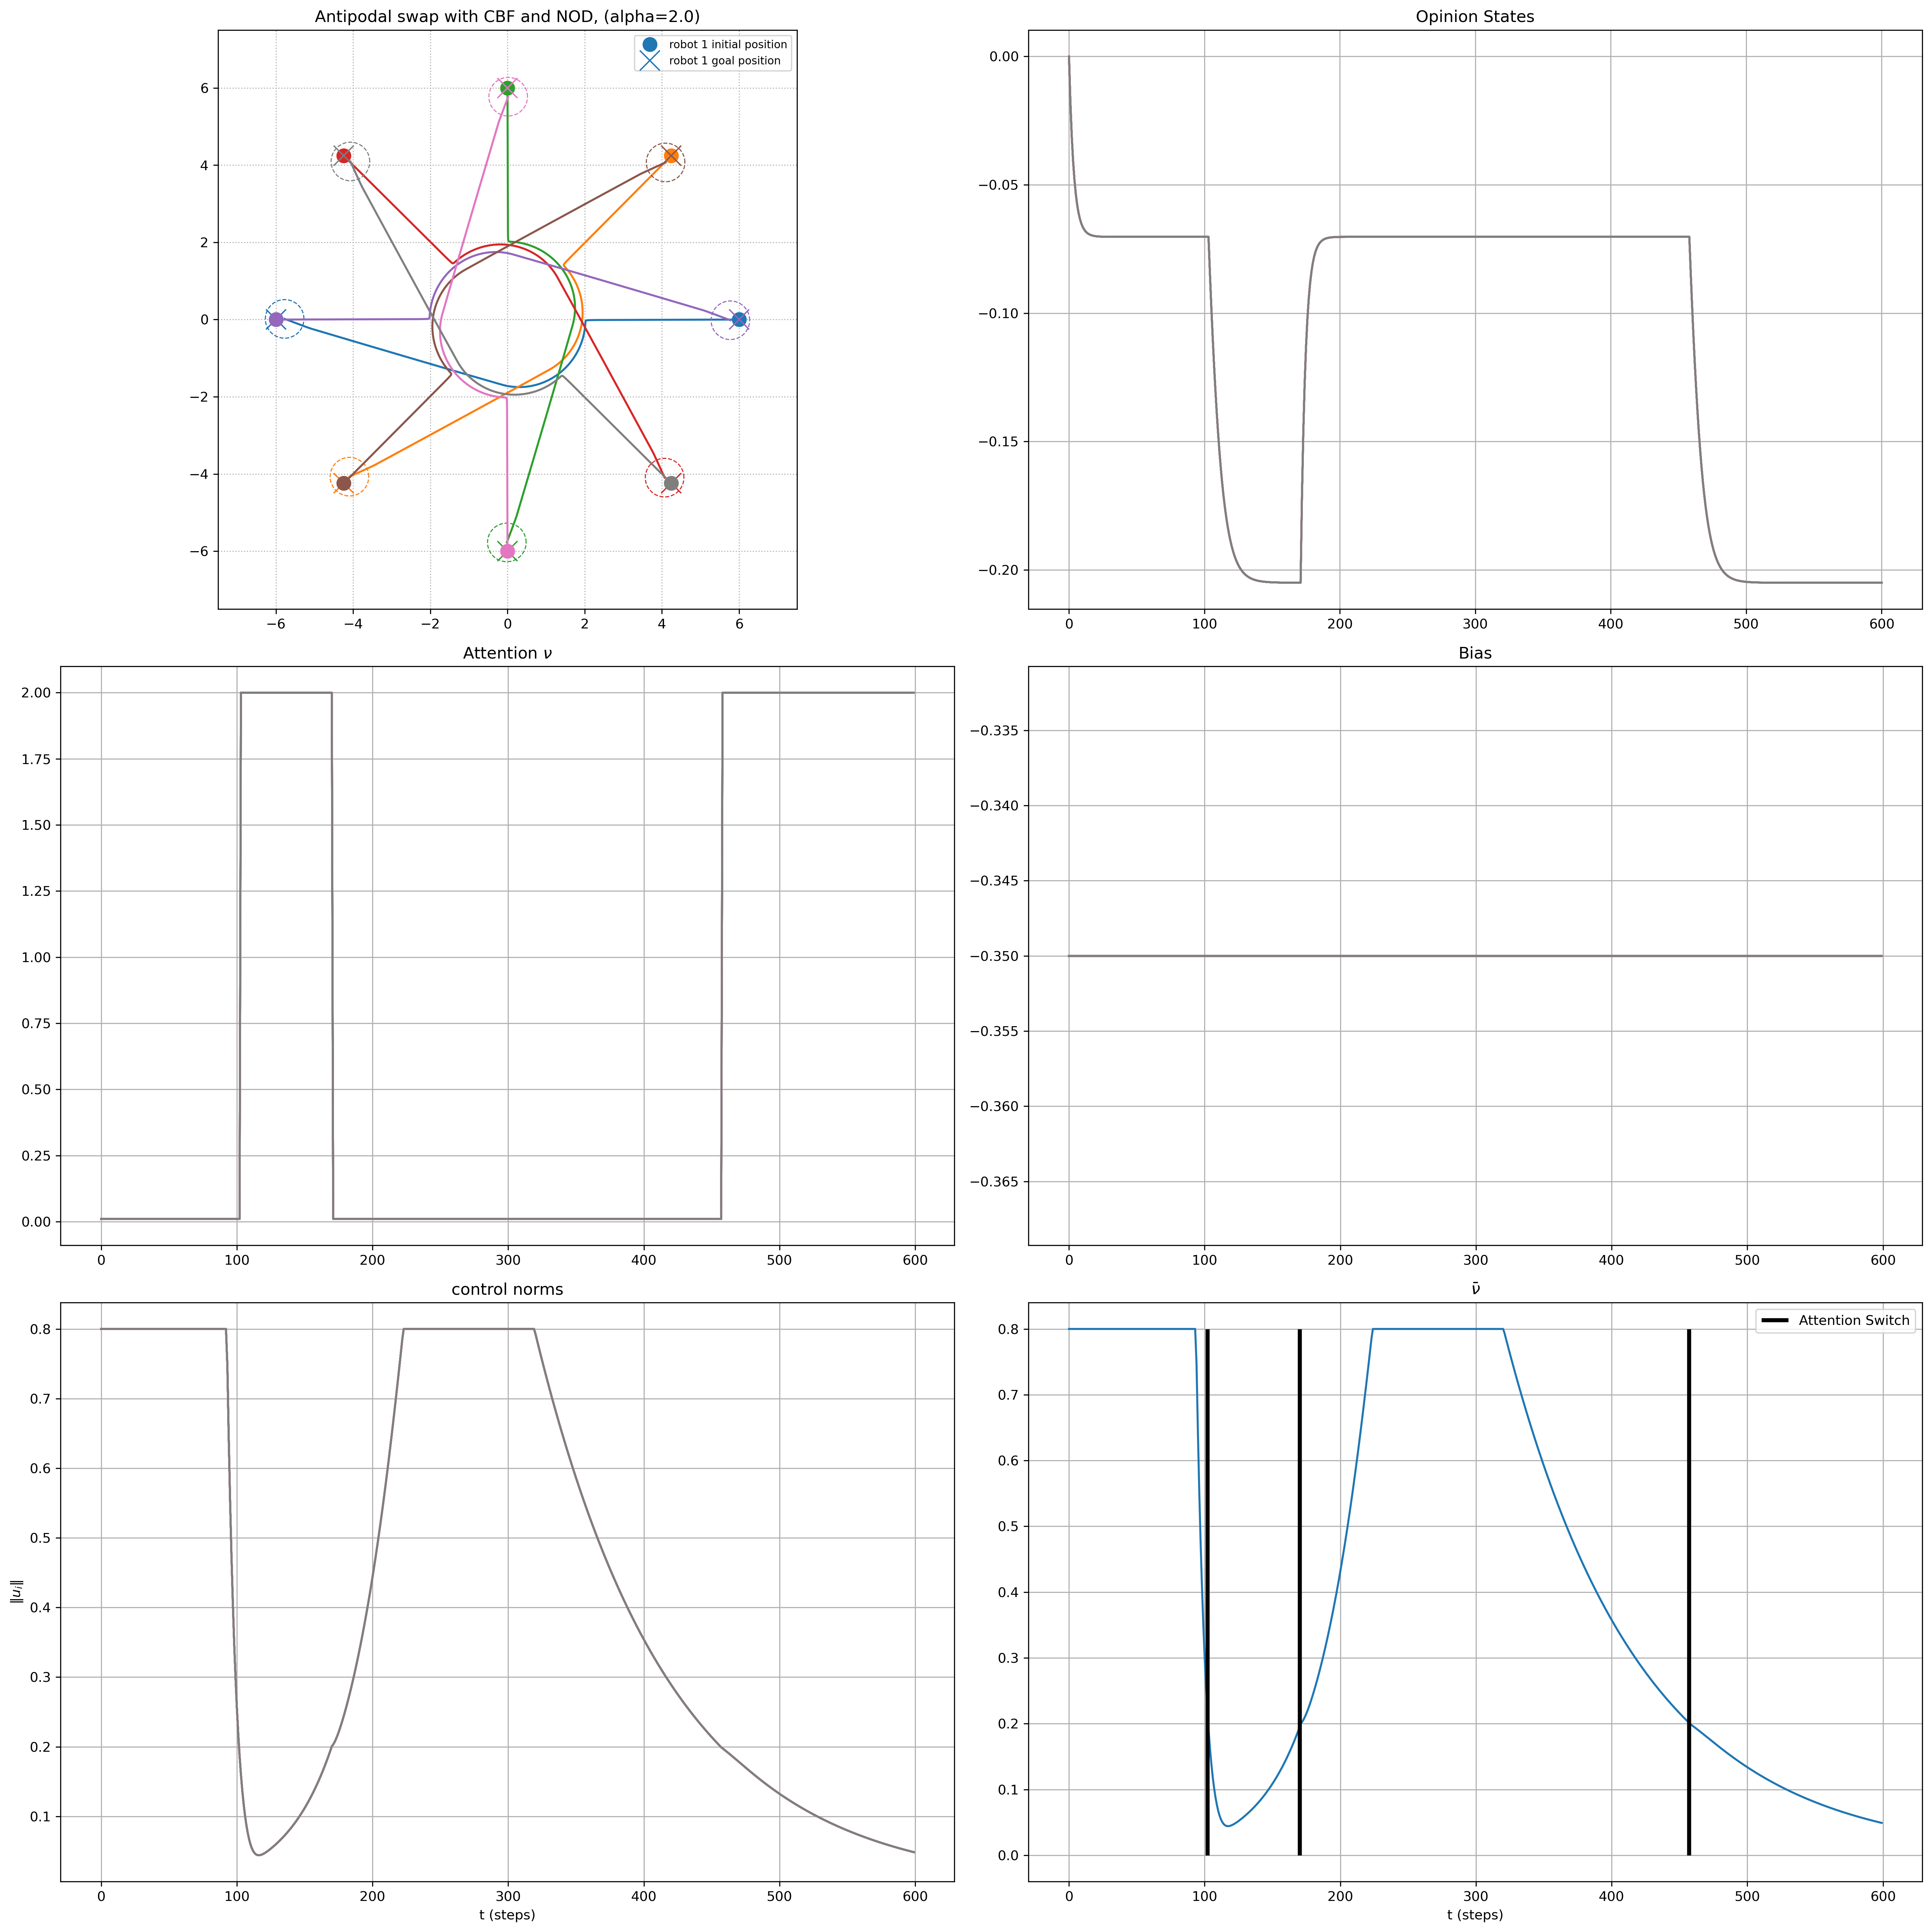

In [14]:
traj = np.asarray(traj)
Us = np.asarray(Us)

plot_every = 2             # draw every k steps (for speed)
trail_len = traj.shape[0]            # number of past positions to show per agent

colors = plt.cm.tab10(np.arange(N) % 10)
fig, ax = plt.subplots(3,2, figsize=(20,20),dpi=300)
ax = ax.flatten()
ax[0].set_aspect('equal', adjustable='box')
ax[0].set_xlim(-R_circle-1.5, R_circle+1.5)
ax[0].set_ylim(-R_circle-1.5, R_circle+1.5)
ax[0].set_title(f"Antipodal swap with {'CBF' if with_cbf else 'no CBF'} and NOD, (alpha={alpha})")

# draw safety disks at final positions (for visualization)
theta = np.linspace(0, 2*np.pi, 60)
circle = np.stack([np.cos(theta), np.sin(theta)], axis=1)

for i in range(N):
    # trail
    tt = traj[-trail_len:, i, :]
    ax[0].plot(tt[:,0], tt[:,1], lw=1.5, color=colors[i])
    # start and goal
    ax[0].plot(X0[i,0], X0[i,1], 'o', color=colors[i], ms=10, label=f"robot {i+1} initial position" if i==0 else None)
    ax[0].plot(G[i,0],  G[i,1],  'x', color=colors[i], ms=15,label=f"robot {i+1} goal position" if i==0 else None)
    # final disk
    circ = X[i] + robot_radius*circle  #+ d_min/2.0 * circle  # half of d_min is visual buffer; true body radius is robot_radius
    ax[0].plot(circ[:,0], circ[:,1], '--', color=colors[i], lw=0.8)

ax[0].legend(loc='upper right', frameon=True, fontsize=8)
ax[0].grid(True, ls=':')

ax[1].set_title("Opinion States")
op_ary = np.asarray(opinion_lst)
for i in range(N):
    ax[1].plot(op_ary[:,i])

nu_ary = np.asarray(nu_lst)
I_ary = np.asarray(I_lst)

switching_times = []
for k  in range(len(nu_ary[:,0])-1):
    if nu_ary[:,0][k] != nu_ary[:,0][k+1]:
        switching_times.append(k)

ax[2].set_title(r"Attention $\nu$")
ax[3].set_title("Bias")
for i in range(N):
    ax[2].plot(nu_ary[:,i])
    ax[3].plot(I_ary[:,i])
    #ax[5].plot(nu_ary[:,i])

ax[4].set_title("control norms")
ax[4].set_xlabel("t (steps)")
ax[4].set_ylabel(r"$\|u_i\|$")
ax[4].grid()

for i in range(N):
    tt = Us[:, i ,:]
    ax[4].plot(np.linalg.norm(Us[:, i ,:],axis = 1))

vbar_ary = np.array(vbar_lst)
ax[5].plot(vbar_ary) 
ax[5].set_title(r"$\bar \nu$")
ax[5].set_xlabel("t (steps)")
#ax[5].set_ylabel(r"$\bar v$")
ax[5].vlines(switching_times,0,0.8, lw = 3, color = "black", label = "Attention Switch")
ax[5].grid(True)
ax[5].legend()

ax[1].grid()
ax[2].grid()
ax[3].grid()
plt.tight_layout()
plt.show()


Constant bias?

Attention is all the same for each agent?

cant plot everything in base case without NOD?

In [15]:
traj[0]

array([[ 6.00000000e+00,  0.00000000e+00],
       [ 4.24264069e+00,  4.24264069e+00],
       [ 3.67394040e-16,  6.00000000e+00],
       [-4.24264069e+00,  4.24264069e+00],
       [-6.00000000e+00,  7.34788079e-16],
       [-4.24264069e+00, -4.24264069e+00],
       [-1.10218212e-15, -6.00000000e+00],
       [ 4.24264069e+00, -4.24264069e+00]])

In [16]:
import numpy as np

def estimate_deadlock_exit(traj, vbar_lst, t_lst, G, eps_form, vmin):
    """
    Detect the first time the system exits deadlock and reaches formation.

    Exit condition (both required):
      1) vbar(t) > vmin
      2) max_i ||p_i(t) - G_i|| < eps_form
    """

    traj = np.asarray(traj)
    vbar = np.asarray(vbar_lst)
    t_arr = np.asarray(t_lst)
    G = np.asarray(G)

    # Align lengths to avoid out-of-bounds
    T = min(traj.shape[0], vbar.shape[0], t_arr.shape[0])
    if T == 0:
        return None, None

    for k in range(T):
        Xk = traj[k]  # shape (N,2)
        max_dev = np.max(np.linalg.norm(Xk - G, axis=1))
        #print(np.linalg.norm(Xk - G, axis=1))
        #print(vbar[k], max_dev)
        # Check both conditions
        if vbar[k] > vmin and max_dev < eps_form:
            return float(t_arr[k]), int(k)

    # If we finish the loop without finding a time, return None
    return None, None


In [17]:
estimate_deadlock_exit(traj, vbar_lst, t_lst, G, 4, 0.7) # 4 since thats when hit circle part. 0.6 is more arbitrary, but want them moving fast

(15.950000000000092, 319)

In [18]:
estimate_deadlock_exit(traj, vbar_lst, t_lst, G, 0.3, 0.01) # 4 since thats when hit circle part. 0.1 is more arbitrary, but want them moving fast

(28.60000000000027, 572)

In [19]:
np.argmin(vbar_ary)

117